<a href="https://colab.research.google.com/github/JEEVIKAV07/Quiz-App/blob/master/Restaurant_Menu_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load Excel dataset
df = pd.read_excel('/content/restaurant_sales_dataset_200_rows.xlsx')

# Show first 5 rows
df.head()

,Order_ID,Date,Item_Name,Category,Quantity_Sold,Selling_Price,Ingredient_Cost
0,1001,17-05-2026,Coffee,Beverage,4,80,25
1,1002,25-05-2026,Noodles,Chinese,2,160,75
2,1003,26-05-2026,Soup,Starter,4,130,55
3,1004,13-05-2026,Cake,Dessert,4,140,60
4,1005,30-05-2026,Pizza,Fast Food,1,300,140


In [2]:
# Revenue
df['Revenue'] = df['Quantity_Sold'] * df['Selling_Price']

# Total Cost
df['Total_Cost'] = df['Quantity_Sold'] * df['Ingredient_Cost']

# Profit
df['Profit'] = df['Revenue'] - df['Total_Cost']

# Display updated dataset
df.head()

,Order_ID,Date,Item_Name,Category,Quantity_Sold,Selling_Price,Ingredient_Cost,Revenue,Total_Cost,Profit
0,1001,17-05-2026,Coffee,Beverage,4,80,25,320,100,220
1,1002,25-05-2026,Noodles,Chinese,2,160,75,320,150,170
2,1003,26-05-2026,Soup,Starter,4,130,55,520,220,300
3,1004,13-05-2026,Cake,Dessert,4,140,60,560,240,320
4,1005,30-05-2026,Pizza,Fast Food,1,300,140,300,140,160


In [3]:
# Total Revenue
print("Total Revenue:", df['Revenue'].sum())

# Total Cost
print("Total Cost:", df['Total_Cost'].sum())

# Total Profit
print("Total Profit:", df['Profit'].sum())

Total Revenue: 96920
Total Cost: 43650
Total Profit: 53270


In [4]:
top_selling = df.groupby('Item_Name')['Quantity_Sold'].sum().sort_values(ascending=False)

print(top_selling)

Item_Name
Cake                    59
Pizza                   59
French Fries            56
Soup                    52
Chicken Biryani         44
Fried Rice              43
Coffee                  41
Ice Cream               38
Burger                  37
Pasta                   35
Paneer Butter Masala    32
Noodles                 31
Sandwich                28
Tea                     28
Mojito                  27
Name: Quantity_Sold, dtype: int64


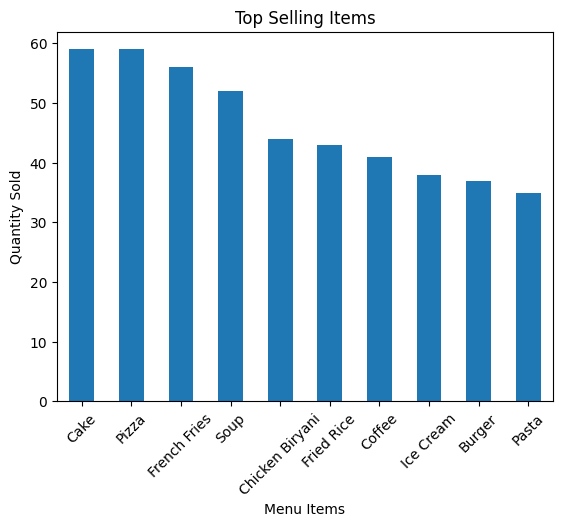

In [5]:
import matplotlib.pyplot as plt

top_selling.head(10).plot(kind='bar')

plt.title("Top Selling Items")
plt.xlabel("Menu Items")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=45)

plt.show()

In [6]:
# Most profitable items
most_profitable = df.groupby('Item_Name')['Profit'].sum().sort_values(ascending=False)

print(most_profitable)

Item_Name
Pizza                   9440
Chicken Biryani         5280
Cake                    4720
Soup                    3900
Fried Rice              3870
Pasta                   3850
Paneer Butter Masala    3840
French Fries            3360
Burger                  2960
Noodles                 2635
Ice Cream               2470
Coffee                  2255
Sandwich                1960
Mojito                  1890
Tea                      840
Name: Profit, dtype: int64


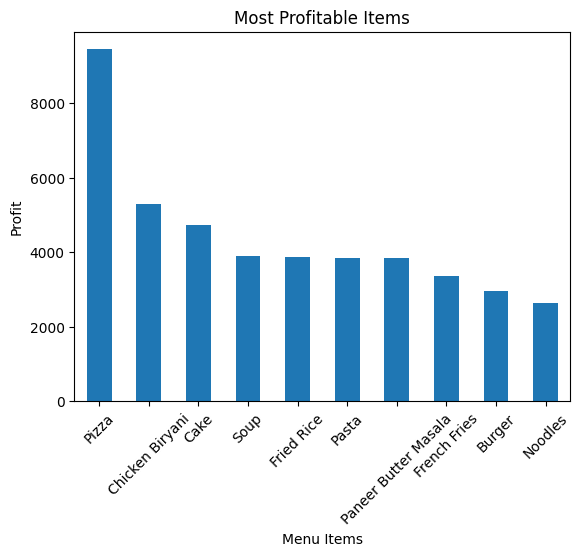

In [7]:
most_profitable.head(10).plot(kind='bar')

plt.title("Most Profitable Items")
plt.xlabel("Menu Items")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.show()

In [8]:
df['Contribution_Margin'] = df['Selling_Price'] - df['Ingredient_Cost']

df.head()

,Order_ID,Date,Item_Name,Category,Quantity_Sold,Selling_Price,Ingredient_Cost,Revenue,Total_Cost,Profit,Contribution_Margin
0,1001,17-05-2026,Coffee,Beverage,4,80,25,320,100,220,55
1,1002,25-05-2026,Noodles,Chinese,2,160,75,320,150,170,85
2,1003,26-05-2026,Soup,Starter,4,130,55,520,220,300,75
3,1004,13-05-2026,Cake,Dessert,4,140,60,560,240,320,80
4,1005,30-05-2026,Pizza,Fast Food,1,300,140,300,140,160,160


In [9]:
# Popularity
popularity = df.groupby('Item_Name')['Quantity_Sold'].sum()

# Average popularity
avg_popularity = popularity.mean()

# Average contribution margin
avg_cm = df.groupby('Item_Name')['Contribution_Margin'].mean().mean()

print("Average Popularity:", avg_popularity)
print("Average Contribution Margin:", avg_cm)

Average Popularity: 40.666666666666664
Average Contribution Margin: 84.66666666666667


In [10]:
menu_df = df.groupby('Item_Name').agg({
    'Quantity_Sold': 'sum',
    'Contribution_Margin': 'mean',
    'Profit': 'sum'
}).reset_index()

menu_df.head()

,Item_Name,Quantity_Sold,Contribution_Margin,Profit
0,Burger,37,80.0,2960
1,Cake,59,80.0,4720
2,Chicken Biryani,44,120.0,5280
3,Coffee,41,55.0,2255
4,French Fries,56,60.0,3360


In [11]:
def classify_item(row):
    if row['Quantity_Sold'] >= avg_popularity and row['Contribution_Margin'] >= avg_cm:
        return 'Star'

    elif row['Quantity_Sold'] >= avg_popularity and row['Contribution_Margin'] < avg_cm:
        return 'Plow Horse'

    elif row['Quantity_Sold'] < avg_popularity and row['Contribution_Margin'] >= avg_cm:
        return 'Puzzle'

    else:
        return 'Dog'

menu_df['Category_Type'] = menu_df.apply(classify_item, axis=1)

menu_df

,Item_Name,Quantity_Sold,Contribution_Margin,Profit,Category_Type
0,Burger,37,80.0,2960,Dog
1,Cake,59,80.0,4720,Plow Horse
2,Chicken Biryani,44,120.0,5280,Star
3,Coffee,41,55.0,2255,Plow Horse
4,French Fries,56,60.0,3360,Plow Horse
5,Fried Rice,43,90.0,3870,Star
6,Ice Cream,38,65.0,2470,Dog
7,Mojito,27,70.0,1890,Dog
8,Noodles,31,85.0,2635,Puzzle
9,Paneer Butter Masala,32,120.0,3840,Puzzle


In [12]:
category_counts = menu_df['Category_Type'].value_counts()

print(category_counts)

Category_Type
Dog           5
Plow Horse    4
Star          3
Puzzle        3
Name: count, dtype: int64


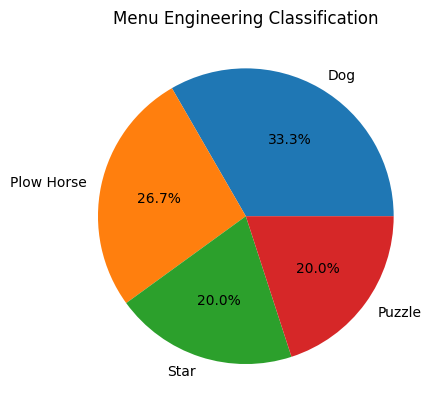

In [13]:
category_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Menu Engineering Classification")

plt.ylabel('')

plt.show()

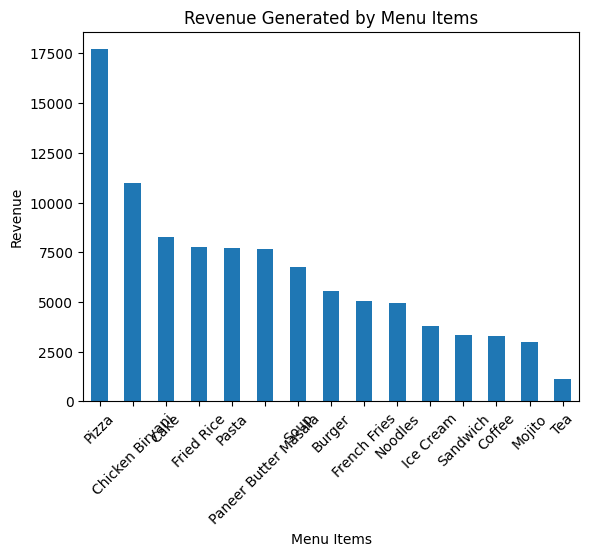

In [14]:
revenue_by_item = df.groupby('Item_Name')['Revenue'].sum().sort_values(ascending=False)

revenue_by_item.plot(kind='bar')

plt.title("Revenue Generated by Menu Items")
plt.xlabel("Menu Items")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

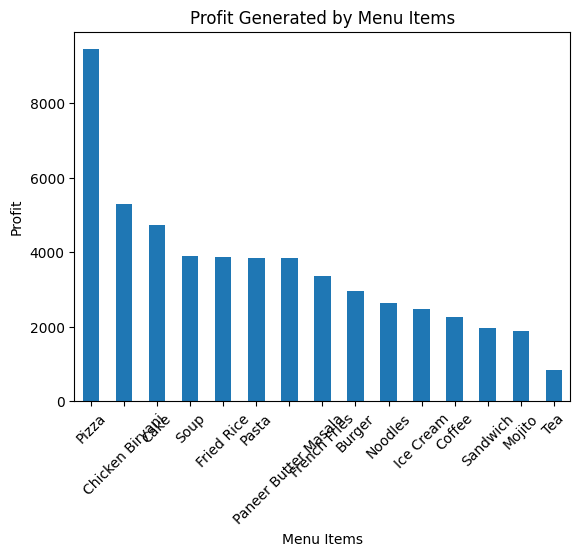

In [15]:
profit_by_item = df.groupby('Item_Name')['Profit'].sum().sort_values(ascending=False)

profit_by_item.plot(kind='bar')

plt.title("Profit Generated by Menu Items")
plt.xlabel("Menu Items")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.show()

In [16]:
least_selling = df.groupby('Item_Name')['Quantity_Sold'].sum().sort_values()

print(least_selling.head(5))

Item_Name
Mojito                  27
Tea                     28
Sandwich                28
Noodles                 31
Paneer Butter Masala    32
Name: Quantity_Sold, dtype: int64


In [17]:
df['Food_Cost_Percentage'] = (
    df['Total_Cost'] / df['Revenue']
) * 100

df[['Item_Name', 'Food_Cost_Percentage']].head()

,Item_Name,Food_Cost_Percentage
0,Coffee,31.250000
1,Noodles,46.875000
2,Soup,42.307692
3,Cake,42.857143
4,Pizza,46.666667


In [18]:
food_cost_analysis = df.groupby('Item_Name')['Food_Cost_Percentage'].mean().sort_values()

print(food_cost_analysis)

Item_Name
Tea                     25.000000
Coffee                  31.250000
French Fries            33.333333
Ice Cream               35.000000
Mojito                  36.363636
Sandwich                41.666667
Soup                    42.307692
Cake                    42.857143
Burger                  46.666667
Pizza                   46.666667
Noodles                 46.875000
Fried Rice              50.000000
Pasta                   50.000000
Paneer Butter Masala    50.000000
Chicken Biryani         52.000000
Name: Food_Cost_Percentage, dtype: float64


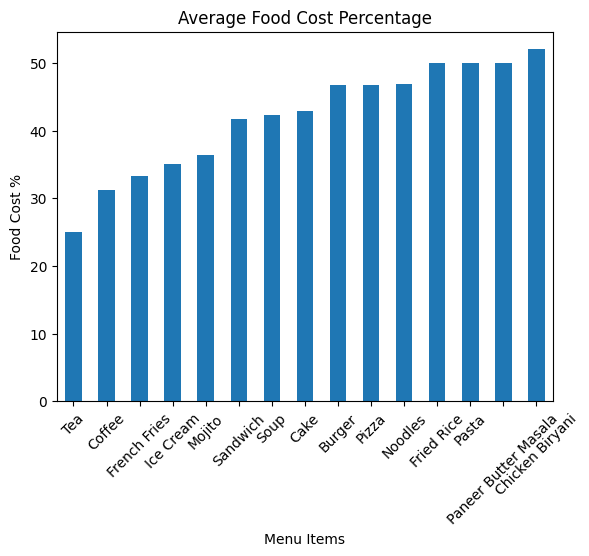

In [19]:
food_cost_analysis.plot(kind='bar')

plt.title("Average Food Cost Percentage")
plt.xlabel("Menu Items")
plt.ylabel("Food Cost %")

plt.xticks(rotation=45)

plt.show()

In [20]:
menu_df.to_excel("menu_engineering_report.xlsx", index=False)

print("Report Exported Successfully")

Report Exported Successfully


In [21]:
df.to_excel("restaurant_sales_final_analysis.xlsx", index=False)

print("Final Dataset Exported")

Final Dataset Exported
